In [4]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [6]:
from src.models.MatrixFactorization import MF, UMF
from src.graphs import random_k_out_graph, create_graph
from src.users import User
from src.training.decentralized import decentralized_train_loop, decentralized_validate_loop, decentralized_train_n_epochs
from src.data_utils import create_batched_dataloaders, create_dataloader

In [7]:
#Make data sample iterable
from torch.utils.data import Dataset, DataLoader, TensorDataset, Sampler
import torch
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import SGD

from collections import Counter
import networkx as nx
from networkx.generators.classic import empty_graph
from networkx.utils import discrete_sequence, py_random_state, weighted_choice

import seaborn as sns

In [8]:
model = "umf"
val_loader_type = "rs"
userprop = 0.6
n_factors = 30
sparse = False
batch_size = 10
graph_seed = 1
n_epochs = 50

para_vec= {
  "scalefree_userprop" : [0.006721468985407216, 0.3793755748581348, 0.7023494584199832],
  "scalefree_urs" : [0.00797255113179729, 0.7291631699209506, 0.7649689575684868],
  "scalefree_rs" : [0.043245636749499355, 0.24293301237845355, 0.6590721600407826],
  "scalefree_oaat" : [0.014505446034196021, 0.1281494707675557, 0.3063931184178566],
    
  "cycle_userprop" : [0.03448020025507248, 0.1530360406099725, 0.3265046312442892],
  "cycle_urs" : [0.015085184891905544, 0.32597756888723617, 0.9165691479123227],
  "cycle_rs" : [0.04518354114581989, 0.07432773840871296, 0.5104116722654509],
  "cycle_oaat" : [0.006051947990064438, 0.407449910177748, 0.6941867781038726],
    
  "random2_userprop" : [0.05973335259492166, 0.20270185084925238, 0.1],
  "random2_urs" : [0.03871364416669273, 0.14214480688557163, 0.4403378739685112],
  "random2_rs" : [0.03871364416669273, 0.14214480688557163, 0.01],
  "random2_oaat" : [0.012098247288774554, 0.051267232285266244, 0.5034632200402083],

  "random5_userprop" : [0.01214468819649195, 0.16071055871166323, 0.8930612583507401],
  "random5_urs" : [0.04664261576162963, 0.2261414992421005, 0.3645222958218734],
  "random5_rs" : [0.01864856189846265, 0.07043500222618476, 0.850748837624225],
  "random5_oaat" : [0.004358629931177893, 0.27784542450084454, 0.41295161556157467]
    
}

In [78]:
search_space_random2out = ["random2_userprop", "random2_urs", "random2_rs", "random2_oaat"]
search_space_random5out = ["random5_userprop", "random5_urs", "random5_rs", "random5_oaat"]
search_space_scalefree = ["scalefree_userprop", "scalefree_urs", "scalefree_rs", "scalefree_oaat"]
search_space_cycle = ["cycle_userprop", "cycle_urs", "cycle_rs", "cycle_oaat"]
model = "umf"
val_loader_type = "rs"
userprop = 0.6
n_factors = 30
sparse = False
batch_size = 10
graph_seed = 1
n_epochs = 80
test_vec = []
commute_vec = []
commute_cost_vec = []
gtypes, dl_types = map(list, zip(*map(lambda x:x.split('_'), search_space)))  

torch.manual_seed(0)


In [112]:
time_table = {}
rmse_table = {}
communte_table = {}
test_table = {}


break_status = False

i = 1
train_loader_type = "urs"
graph_type = "random_5_out"
print(train_loader_type)
temp_para = para_vec[search_space_random5out[i]]
lr = temp_para[0]
weight_decay = temp_para[1]
mom = temp_para[2]
print(f"lr : {lr} | wd : {weight_decay} | mom : {mom}")

for order in [1,2,3,4,5]:
        train_df = pd.read_csv("dataset/ml100k_train_seed10.csv")
        test_df = pd.read_csv("dataset/ml100k_test_seed10.csv")
        n_users = train_df['user_id'].nunique()
        n_items = train_df['item_id'].nunique() 
        
        train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=0)
        train_data_loader = create_dataloader(
            df=train_df, dl_type=train_loader_type, batch_size=batch_size, p=0.6
            )
        val_data_loader = create_dataloader(df=val_df, dl_type=val_loader_type)
        test_data_loader = create_dataloader(df=test_df, dl_type=val_loader_type)
        
        users = {}
        for i in tqdm(range(n_users)):
            # model = MF(n_users=n_users, n_items=n_items)
            user_model = UMF(n_items, n_factors = n_factors, sparse = sparse)
            # model = GeneralizedMFOneLayer(n_users=n_users, n_items=n_items)
            users[i] = User(id=i, model=user_model, optimizer=SGD(user_model.parameters(), lr=lr, weight_decay=weight_decay,momentum=mom), model_name = model)
        
        graph = create_graph(graph_type=graph_type, n_users=n_users, seed=graph_seed, order=order)
        graph = graph.to_undirected()
        train_losses, val_losses, time_per_epoch, commutes = decentralized_train_n_epochs(
                user_models=users,
                train_loader=train_data_loader,
                val_loader=val_data_loader,
                epochs=n_epochs,
                graph=graph,
                break_gate = break_status
                )  
        test_loss = decentralized_validate_loop(users, test_data_loader)
        
        time_table[order] = time_per_epoch
        rmse_table[order] = val_losses
        communte_table[order] = commutes["commute"]
        test_table[order] = test_loss


urs
lr : 0.04664261576162963 | wd : 0.2261414992421005 | mom : 0.3645222958218734


  0%|          | 0/943 [00:00<?, ?it/s]

  0%|          | 0/943 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 2.0516 | Validation Loss: 4.5265 | Time Elapsed: 2.725463 sec |Commute: 9398 | Commute Cost: 
47737489

  0%|          | 0/943 [00:00<?, ?it/s]

...

Epoch 9 | Train Loss: 0.4913 | Validation Loss: 1.2407 | Time Elapsed: 68.460396 sec |Commute: 888234 | Commute 
Cost: 47737489

  0%|          | 0/943 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.4553 | Validation Loss: 1.1600 | Time Elapsed: 69.179940 sec |Commute: 888234 | Commute 
Cost: 47737489

  0%|          | 0/943 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [116]:
df = pd.DataFrame.from_dict(time_table, orient="index")
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("time_table_order_random5out.csv", index=False)

In [118]:
df = pd.DataFrame.from_dict(rmse_table, orient="index")
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("rmse_table_order_random5out.csv", index=False)

In [120]:
df = pd.DataFrame.from_dict(communte_table, orient="index")
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("commute_table_order_random5out.csv", index=False)

In [122]:
df = pd.DataFrame.from_dict( test_table, orient="index")
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("test_loss_order_random5out.csv", index=False)

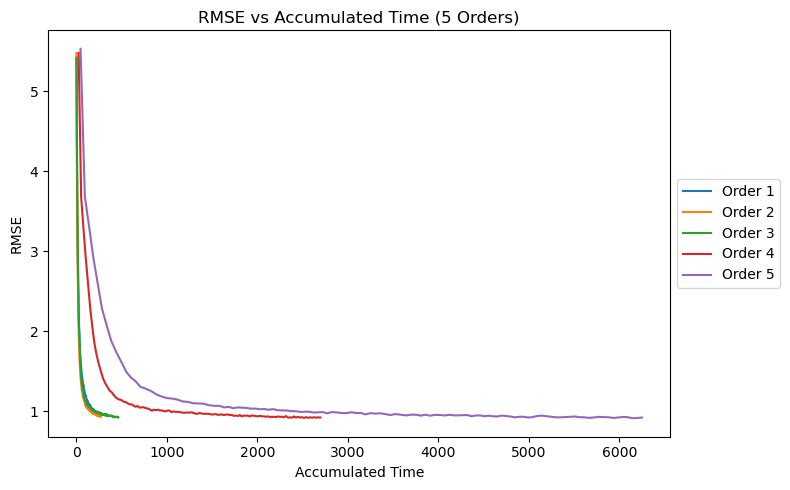

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the new data
rmse_df = pd.read_csv('ResultData/June30/order/rmse_table_order_random2out.csv')
time_df = pd.read_csv('ResultData/June30/order/time_table_order_random2out.csv')

plt.figure(figsize=(8,5))

# Plot for 5 orders
for i in range(5):
    rmse = rmse_df.iloc[i, 1:].astype(float).values
    time = time_df.iloc[i, 1:].astype(float).values.cumsum()
    min_len = min(len(time), len(rmse))
    plt.plot(time[:min_len], rmse[:min_len], label=f'Order {i+1}')

plt.xlabel('Accumulated Time')
plt.ylabel('RMSE')
plt.title('RMSE vs Accumulated Time (5 Orders)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig('ResultData/June30/order/order_cycle.png')
plt.show()